# Module 5.D - NYC 311 Tree-Based Methods  
**Decision Trees, Random Forests, and Gradient Boosting on NYC 311**

This notebook gives you hands-on practice with the tree-based methods from **Module 5.D** using the NYC 311 artifacts saved in **Module 5.C**.

You will:

- Load the cleaned NYC 311 feature table from **5.C**
- Use the same **random split protocol** as earlier notebooks
- Use a robust `build_preprocessor()` function to avoid NaNs and dtype issues
- Train:
  - a **Decision Tree**
  - a **Random Forest**
  - a **Gradient Boosting** model
- Compare them to a simple baseline
- Evaluate both:
  - **Regression**: predict `resolution_hours`
  - **Classification**: predict `is_closed`
- Inspect feature importance
- Run slice analysis by **agency** / **borough**
- Write a short model-choice memo

---

## Reminder about this dataset
This table covers only about **6 days** (~50k rows). Because of that:

- **Do not** split by time here
- Use **random splits**
- For regression, use only rows where `resolution_hours` is known
- For classification, keep in mind that `is_closed=0` can include cases that close later (label noise / censoring)

This notebook follows the same early setup style as **5.A**, **5.B**, and **5.C**.

In [1]:
# === Setup ===
import os, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

from sklearn.tree import (
    DecisionTreeRegressor, DecisionTreeClassifier,
    plot_tree
)
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

SEED = 42
rng = np.random.default_rng(SEED)

## 5D.1 - Load v2 Artifacts From 5C

In [2]:
# === Paths ===
ARTIFACT_DIR = Path("work/m5/artifacts/nyc311")
clean_path = ARTIFACT_DIR / "nyc311_features_clean_v2.parquet"
config_path = ARTIFACT_DIR / "feature_config.json"

def load_df():
    if clean_path.exists():
        return pd.read_parquet(clean_path), "m5_artifact_clean_v2"
    raise FileNotFoundError(f"Could not find parquet at {clean_path}")

df, df_source = load_df()
print("Loaded source:", df_source)
print("Shape:", df.shape)
display(df.head(3))

Loaded source: m5_artifact_clean_v2
Shape: (50000, 25)


,unique_key,created_date,created_day,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,closed_rate,median_resolution_hours,agency_n_requests,agency_closed_rate,agency_median_resolution,status,is_closed,resolution_hours,_source,created_dow
0,67720523,2026-01-30 01:51:21,2026-01-30,1,4,0,NYPD,(missing),other,1,1,0,0,NaN,280,0.435714,0.480972,11651,0.981890,1.277778,Unspecified,0,NaN,2.C_features_parquet,4
1,67746090,2026-01-30 01:51:04,2026-01-30,1,4,0,DOE,BROOKLYN,other,0,0,0,0,911.0,280,0.435714,0.480972,144,0.520833,7.605000,In Progress,0,NaN,2.C_features_parquet,4
2,67758820,2026-01-30 01:50:53,2026-01-30,1,4,0,NYPD,MANHATTAN,noise - residential,0,1,0,0,936.0,280,0.435714,0.480972,11651,0.981890,1.277778,In Progress,0,NaN,2.C_features_parquet,4


In [3]:
# Load feature config if available
config = None
if config_path.exists():
    config = json.loads(config_path.read_text())
    print("Loaded config keys:", sorted(list(config.keys())))
else:
    print("No feature_config.json found at:", config_path)


Loaded config keys: ['agg_cols_suspect', 'all_drop', 'all_features_regression', 'id_cols', 'notes', 'outcome_revealers', 'safe_drop', 'safe_features_regression', 'target_regression', 'time_cols']


## 5D.2 - Build a Preprocessing Function  

Even tree-based models need a reliable pipeline when your dataframe contains:

- missing numeric values
- object/string categoricals
- datetimes
- mixed dtypes

We will:

- impute numeric columns with the median
- impute categoricals with the most frequent value
- one-hot encode categoricals
- standardize numeric columns

Strictly speaking, trees do not *need* scaling the way linear models do.  
But keeping the preprocessing pipeline aligned with earlier notebooks makes the workflow stable and predictable.

In [4]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

def describe_cols(X: pd.DataFrame):
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols

## 5D.3 - Define SAFE vs ALL feature sets  
As in the earlier notebooks, we build a leakage-aware SAFE feature set.

Why this matters here:
- Trees are powerful enough to exploit leakage aggressively
- “Too-good-to-be-true” tree performance often *is* leakage

We will use the same config from 5.A if available.

In [5]:
DEFAULT_ID_COLS = ["unique_key", "_source"]
DEFAULT_TIME_COLS = ["created_date", "created_day"]
DEFAULT_OUTCOME = ["status", "is_closed", "resolution_hours"]

safe_drop = set()
all_drop = set()

if config is not None:
    safe_drop |= set(config.get("safe_drop", []))
    all_drop  |= set(config.get("all_drop", []))
else:
    safe_drop |= set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS + DEFAULT_OUTCOME)
    all_drop  |= set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS)

safe_drop |= set(["is_closed", "status", "resolution_hours"])
all_drop  |= set(["is_closed", "resolution_hours"])

def build_X(df_in, drop_cols):
    cols = [c for c in df_in.columns if c not in drop_cols]
    return df_in[cols].copy(), cols

print("SAFE_DROP sample:", sorted(list(safe_drop))[:20])
print("ALL_DROP sample :", sorted(list(all_drop))[:20])


SAFE_DROP sample: ['_source', 'agency_closed_rate', 'agency_median_resolution', 'agency_n_requests', 'closed_rate', 'created_date', 'created_day', 'is_closed', 'median_resolution_hours', 'resolution_hours', 'status', 'unique_key']
ALL_DROP sample : ['_source', 'created_date', 'created_day', 'is_closed', 'resolution_hours', 'status', 'unique_key']


## 5D.4 - Split Protocol (train/val/test)  
Because the dataset spans only ~6 days, temporal splits would create strong right-censoring artifacts.

So we follow the same split logic used earlier:

Train: 70%
Validation: 15%
Test: 15%
Regression uses closed-only rows.
Classification uses the full table with stratification.

In [6]:
def split_random(X, y, stratify=None, seed=SEED, train=0.70, val=0.15, test=0.15):
    assert abs(train + val + test - 1.0) < 1e-9

    Xtr, Xtmp, ytr, ytmp = train_test_split(
        X, y, test_size=(1-train), random_state=seed, stratify=stratify
    )

    val_frac_of_tmp = val / (val + test)
    Xva, Xte, yva, yte = train_test_split(
        Xtmp, ytmp, test_size=(1-val_frac_of_tmp), random_state=seed,
        stratify=(ytmp if stratify is not None else None)
    )
    return Xtr, Xva, Xte, ytr, yva, yte

## 5D.5 - Shared Helpers for Evaluation  
We’ll use the same basic helpers throughout the notebook so that all models are compared consistently

In [7]:
def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

def regression_report(y_true, yhat, label=""):
    abs_err = np.abs(y_true - yhat)
    return {
        "label": label,
        "MAE": float(mean_absolute_error(y_true, yhat)),
        "RMSE": rmse(y_true, yhat),
        "R2": float(r2_score(y_true, yhat)),
        "MedianAbsErr": float(np.median(abs_err)),
        "P90AbsErr": float(np.quantile(abs_err, 0.90)),
        "P95AbsErr": float(np.quantile(abs_err, 0.95)),
    }

def eval_probs(y_true, p, threshold=0.5, label=""):
    yhat = (p >= threshold).astype(int)
    out = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat, zero_division=0)),
        "recall": float(recall_score(y_true, yhat, zero_division=0)),
        "f1": float(f1_score(y_true, yhat, zero_division=0)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except Exception:
        out["roc_auc"] = float("nan")
    try:
        out["avg_precision"] = float(average_precision_score(y_true, p))
    except Exception:
        out["avg_precision"] = float("nan")
    return out

def threshold_sweep(y_true, p, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)
    rows = []
    for t in thresholds:
        rows.append(eval_probs(y_true, p, threshold=float(t)))
    return pd.DataFrame(rows)

def confusion_counts(y_true, p, t):
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
    return int(tp), int(fp), int(tn), int(fn)

# PART 1 - Regression with Tree-Based Methods  
Target: **`resolution_hours`**

We will:
- use **closed-only** rows
- compare a shallow single tree, a random forest, and gradient boosting
- inspect residuals and slice errors
- compare feature importance across models

**Note:** Remember in the 5.C notebook we discovered the dataset could contain negative `resolution_hours` when cases had been reopened. Make sure these are removed before modeling.

In [8]:
# === Regression dataset ===
if "resolution_hours" not in df.columns:
    raise ValueError("resolution_hours not found.")

# --- Diagnose reopened cases (negative durations) ---
n_total = len(df)
n_missing = int(df["resolution_hours"].isna().sum())
n_negative = int((df["resolution_hours"].fillna(0) < 0).sum())

print("Total rows:", n_total)
print("Rows with missing resolution_hours (open cases):", n_missing)
print("Rows with negative resolution_hours (reopened cases):", n_negative)

# --- Build regression dataset ---
# Use only rows where resolution_hours is known AND non-negative
df_reg = df[df["resolution_hours"].notna()].copy()
df_reg = df_reg[df_reg["resolution_hours"] >= 0].copy()

print("\nRegression rows after filtering:", len(df_reg))
print("Rows removed due to negative resolution_hours:", n_negative)

y_reg = df_reg["resolution_hours"].astype(float).to_numpy()

safe_features_regression = None
if config is not None:
    safe_features_regression = config.get("safe_features_regression")

if safe_features_regression is not None:
    reg_cols = [c for c in safe_features_regression if c in df_reg.columns]
    X_reg = df_reg[reg_cols].copy()
    print("Using config safe_features_regression. Count:", len(reg_cols))
else:
    reg_drop = set(config.get("safe_drop", [])) if config is not None else set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS + DEFAULT_OUTCOME)
    reg_drop |= set(["is_closed", "status", "resolution_hours"])
    X_reg, reg_cols = build_X(df_reg, reg_drop)
    print("Using heuristic SAFE regression cols. Count:", len(reg_cols))

Xtr_r, Xva_r, Xte_r, ytr_r, yva_r, yte_r = split_random(X_reg, y_reg, stratify=None)

pre_r = build_preprocessor(Xtr_r)
num_r, cat_r, dt_r = describe_cols(Xtr_r)

print("Regression rows used:", len(df_reg))
print("Split sizes:", len(ytr_r), len(yva_r), len(yte_r))
print("Feature types:", len(num_r), "numeric |", len(cat_r), "categorical |", len(dt_r), "datetime dropped")

display(Xtr_r.head(3))

Total rows: 50000
Rows with missing resolution_hours (open cases): 31106
Rows with negative resolution_hours (reopened cases): 0

Regression rows after filtering: 18894
Rows removed due to negative resolution_hours: 0
Using config safe_features_regression. Count: 13
Regression rows used: 18894
Split sizes: 13225 2834 2835
Feature types: 10 numeric | 3 categorical | 0 datetime dropped


,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,created_dow
49084,8,1,0,NYPD,BROOKLYN,illegal parking,0,0,0,0,7922.0,17529,1
16445,22,2,0,NYPD,BRONX,noise - residential,0,1,0,0,480.0,16913,2
20260,17,2,0,DSNY,BROOKLYN,snow or ice,0,0,0,0,7211.0,16913,2


## 5D.6 - Baseline: Mean Predictor  
Before using tree models, always compare against a trivial baseline.

In [9]:
y_mean = float(np.mean(ytr_r))
yhat_mean = np.full_like(yte_r, y_mean)
base_reg = regression_report(yte_r, yhat_mean, label="mean_predictor_test")
pd.DataFrame([base_reg])

,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr
0,mean_predictor_test,9.848732,13.018731,-0.000003,7.891017,19.496483,29.823594


## 5D.7 - Train Three Regression Models
We’ll train:

1. **DecisionTreeRegressor**
2. **RandomForestRegressor**
3. **GradientBoostingRegressor**

We tune a few simple hyperparameters on validation.

---

### Explanation: Hyperparameter tuning across model families

Tree-based models have different **control knobs** depending on the algorithm.  
Rather than performing a huge grid search, we run a small set of reasonable experiments and compare them on the **validation set**.

The goal here is not exhaustive optimization — it is to understand **how model capacity changes performance** and which model family works best for this dataset.

| Model | Key hyperparameters | What they control |
|------|------|------|
| Decision Tree | `max_depth` | Maximum number of sequential splits (tree complexity) |
| Random Forest | `n_estimators`, `max_depth` | Number of trees and complexity of each tree |
| Gradient Boosting | `learning_rate`, `n_estimators` | Size of each correction and number of boosting stages |

We then evaluate each configuration using the same metrics:

- **MAE** — typical prediction error  
- **RMSE** — tail-sensitive error (large mistakes matter more)  
- **R²** — improvement relative to predicting the mean

Using the **validation set** ensures we choose hyperparameters that generalize rather than simply memorizing the training data.

---

### Why the tuning table contains NaN values

The results table compares **multiple model families** in a single dataframe.

Each model family has **different hyperparameters**, so some columns do not apply to certain models.

| Model | max_depth | n_estimators | learning_rate |
|------|------|------|------|
| Decision Tree | ✓ | — | — |
| Random Forest | ✓ | ✓ | — |
| Gradient Boosting | — | ✓ | ✓ |

When a hyperparameter does not apply to a model, the table shows **NaN**.

#### **Note:** The below code cell performs a hyperparameter tuning search and so may take several minutes to execute.


In [10]:
reg_results = []
reg_models = {}

# Decision Tree parameters
for depth in [3, 5, 8, 12]:
    pipe = Pipeline([
        ("pre", pre_r),
        ("model", DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=20,
            random_state=SEED
        ))
    ])
    pipe.fit(Xtr_r, ytr_r)
    rep = regression_report(yva_r, pipe.predict(Xva_r), label=f"tree_depth_{depth}_val")
    rep["model_family"] = "DecisionTree"
    rep["max_depth"] = depth
    reg_results.append(rep)
    reg_models[rep["label"]] = pipe

# Random Forest parameters
for n_est in [100, 250]:
    for depth in [None, 8, 12]:
        pipe = Pipeline([
            ("pre", pre_r),
            ("model", RandomForestRegressor(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=10,
                n_jobs=-1,
                random_state=SEED
            ))
        ])
        pipe.fit(Xtr_r, ytr_r)
        rep = regression_report(yva_r, pipe.predict(Xva_r), label=f"rf_n{n_est}_d{depth}_val")
        rep["model_family"] = "RandomForest"
        rep["n_estimators"] = n_est
        rep["max_depth"] = depth
        reg_results.append(rep)
        reg_models[rep["label"]] = pipe

# Gradient Boosting parameters
for lr in [0.03, 0.08]:
    for n_est in [100, 250]:
        pipe = Pipeline([
            ("pre", pre_r),
            ("model", GradientBoostingRegressor(
                learning_rate=lr,
                n_estimators=n_est,
                max_depth=3,
                subsample=0.8,
                random_state=SEED
            ))
        ])
        pipe.fit(Xtr_r, ytr_r)
        rep = regression_report(yva_r, pipe.predict(Xva_r), label=f"gbr_lr{lr}_n{n_est}_val")
        rep["model_family"] = "GradientBoosting"
        rep["learning_rate"] = lr
        rep["n_estimators"] = n_est
        reg_results.append(rep)
        reg_models[rep["label"]] = pipe

reg_val = pd.DataFrame(reg_results).sort_values("RMSE")
reg_val_display = reg_val.copy()
reg_val_display["max_depth"] = reg_val_display["max_depth"].astype(object)
mask = (
    ( (reg_val_display["model_family"] == "RandomForest") | (reg_val_display["model_family"] == "DecisionTree") ) &
    (reg_val_display["max_depth"].isna())
)

reg_val_display.loc[mask, "max_depth"] = "None"

display(reg_val_display.head(12))

,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,model_family,max_depth,n_estimators,learning_rate
4,rf_n100_dNone_val,3.974271,7.010927,0.696019,1.417996,12.059143,17.113907,RandomForest,None,100.0,NaN
7,rf_n250_dNone_val,3.980049,7.012448,0.695887,1.432330,12.138698,17.183776,RandomForest,None,250.0,NaN
6,rf_n100_d12_val,4.021197,7.019081,0.695312,1.447176,12.048156,16.778965,RandomForest,12.0,100.0,NaN
9,rf_n250_d12_val,4.027087,7.023971,0.694887,1.457471,12.241405,16.845723,RandomForest,12.0,250.0,NaN
8,rf_n250_d8_val,4.153899,7.117882,0.686674,1.533457,12.446994,16.751355,RandomForest,8.0,250.0,NaN
5,rf_n100_d8_val,4.150989,7.123440,0.686184,1.538912,12.347073,17.021515,RandomForest,8.0,100.0,NaN
13,gbr_lr0.08_n250_val,4.297345,7.214533,0.678107,1.747665,12.856211,17.274428,GradientBoosting,NaN,250.0,0.08
2,tree_depth_8_val,4.246409,7.276039,0.672595,1.566202,12.313880,17.212008,DecisionTree,8.0,NaN,NaN
3,tree_depth_12_val,4.168505,7.289146,0.671414,1.539197,13.078747,17.178794,DecisionTree,12.0,NaN,NaN
11,gbr_lr0.03_n250_val,4.439121,7.346387,0.666233,1.761840,13.049245,17.656016,GradientBoosting,NaN,250.0,0.03


In [11]:
best_reg_row = reg_val.iloc[0]
best_reg_label = best_reg_row["label"]
best_reg_model = reg_models[best_reg_label]

print("Best regression model on validation:")
display(best_reg_row.to_frame().T)

yhat_te_r = best_reg_model.predict(Xte_r)

print("Best regression model vs baseline mean predictor on test:")
test_best_reg = regression_report(yte_r, yhat_te_r, label=best_reg_label.replace("_val", "_test"))
pd.DataFrame([base_reg, test_best_reg]).sort_values("RMSE")


Best regression model on validation:


,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,model_family,max_depth,n_estimators,learning_rate
4,rf_n100_dNone_val,3.974271,7.010927,0.696019,1.417996,12.059143,17.113907,RandomForest,NaN,100.0,NaN


Best regression model vs baseline mean predictor on test:


,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr
1,rf_n100_dNone_test,4.286668,7.490021,0.668998,1.555629,13.256671,17.871220
0,mean_predictor_test,9.848732,13.018731,-0.000003,7.891017,19.496483,29.823594


## 5D.8 Residual diagnostics (regression)

Even if overall RMSE looks good, tree regressors can still fail in systematic ways.


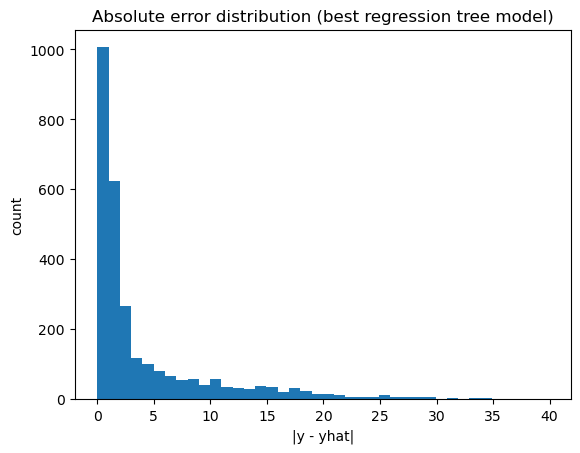

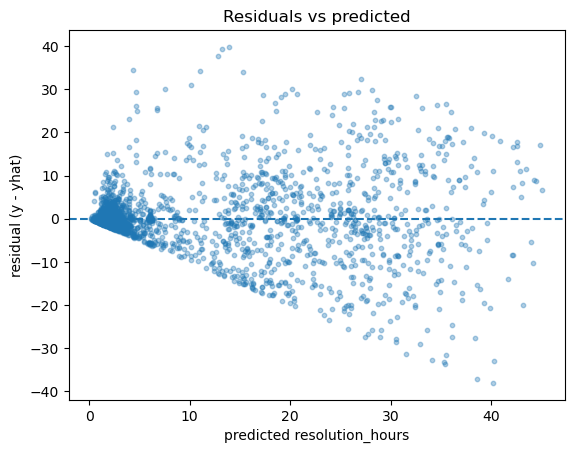

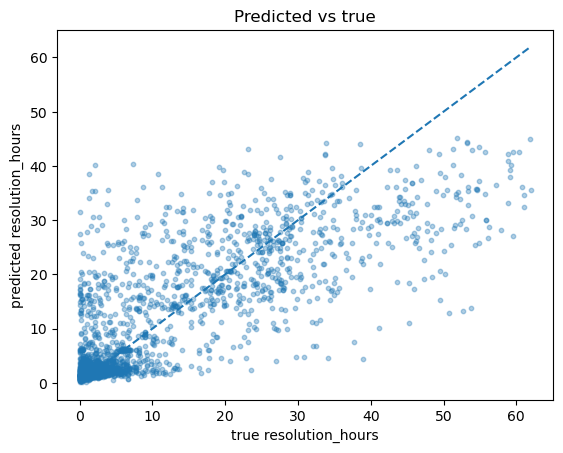

Median abs error: 1.555629180040795
P90 abs error: 13.256670686382666
P95 abs error: 17.871219681330803


In [12]:
resid = yte_r - yhat_te_r
abs_err = np.abs(resid)

plt.figure()
plt.hist(abs_err, bins=40)
plt.title("Absolute error distribution (best regression tree model)")
plt.xlabel("|y - yhat|")
plt.ylabel("count")
plt.show()

plt.figure()
plt.scatter(yhat_te_r, resid, s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs predicted")
plt.xlabel("predicted resolution_hours")
plt.ylabel("residual (y - yhat)")
plt.show()

plt.figure()
plt.scatter(yte_r, yhat_te_r, s=10, alpha=0.35)
mn = float(min(yte_r.min(), yhat_te_r.min()))
mx = float(max(yte_r.max(), yhat_te_r.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title("Predicted vs true")
plt.xlabel("true resolution_hours")
plt.ylabel("predicted resolution_hours")
plt.show()

print("Median abs error:", float(np.median(abs_err)))
print("P90 abs error:", float(np.quantile(abs_err, 0.90)))
print("P95 abs error:", float(np.quantile(abs_err, 0.95)))


## 5D.9 Slice evaluation for regression

We compute slice metrics by:
- `agency`
- `borough_norm`


In [13]:
df_test_reg = df_reg.loc[Xte_r.index].copy()
df_test_reg["y_true"] = yte_r
df_test_reg["y_pred"] = yhat_te_r
df_test_reg["abs_err"] = np.abs(df_test_reg["y_true"] - df_test_reg["y_pred"])
df_test_reg["sq_err"] = (df_test_reg["y_true"] - df_test_reg["y_pred"])**2

# --- agency slices ---
by_agency_reg = (
    df_test_reg
    .groupby("agency")
    .agg(
        n=("abs_err", "size"),
        MAE=("abs_err", "mean"),
        MSE=("sq_err", "mean"),
        P90AbsErr=("abs_err", lambda x: np.quantile(x, 0.90)),
    )
)

by_agency_reg["RMSE"] = np.sqrt(by_agency_reg["MSE"])
by_agency_reg = by_agency_reg.drop(columns="MSE").sort_values("RMSE", ascending=False)

# --- borough slices ---
by_boro_reg = (
    df_test_reg
    .groupby("borough_norm")
    .agg(
        n=("abs_err", "size"),
        MAE=("abs_err", "mean"),
        MSE=("sq_err", "mean"),
        P90AbsErr=("abs_err", lambda x: np.quantile(x, 0.90)),
    )
)

by_boro_reg["RMSE"] = np.sqrt(by_boro_reg["MSE"])
by_boro_reg = by_boro_reg.drop(columns="MSE").sort_values("RMSE", ascending=False)

display(by_agency_reg.head(12))
display(by_boro_reg)

,n,MAE,P90AbsErr,RMSE
agency,,,,
DOE,12,12.931847,18.512523,15.364703
DHS,36,12.346881,22.583376,14.692011
TLC,7,8.635362,21.376708,14.112344
DPR,13,10.891327,21.386122,12.982010
HPD,690,9.435048,19.489725,12.075375
DOB,21,8.826115,17.116676,10.590166
DSNY,123,6.855039,19.220833,10.359711
DOT,114,6.751293,15.012914,10.347089
DEP,112,5.129084,12.754871,8.208391


,n,MAE,P90AbsErr,RMSE
borough_norm,,,,
MANHATTAN,435,6.457330,17.610899,10.004113
BRONX,681,4.770894,13.340196,7.911727
BROOKLYN,925,4.001623,11.553007,7.069102
STATEN ISLAND,110,3.636605,12.145641,6.783040
QUEENS,684,2.914123,7.523689,5.619002


## 5D.9 - Regression Feature Importance
We inspect impurity-based feature importance from the best regression model if it supports it

In [14]:
best_reg_core = best_reg_model.named_steps["model"]
pre_best_reg = best_reg_model.named_steps["pre"]
reg_feature_names = list(pre_best_reg.get_feature_names_out())

if hasattr(best_reg_core, "feature_importances_"):
    imp_reg = pd.DataFrame({
        "feature": reg_feature_names,
        "importance": best_reg_core.feature_importances_
    }).sort_values("importance", ascending=False)
    display(imp_reg.head(20))
else:
    print("Best regression model does not expose feature_importances_.")

,feature,importance
19,agency_HPD,0.357441
20,agency_NYPD,0.282083
8,n_requests,0.073587
7,street_number,0.073432
0,created_hour,0.043619
1,dayofweek,0.039046
9,created_dow,0.034948
39,complaint_topk_snow or ice,0.016452
32,complaint_topk_heat/hot water,0.011701
40,complaint_topk_traffic signal condition,0.009863


# PART II - Classification with Tree-Based Methods  
Target: `is_closed`

We will:

compare a single decision tree, random forest, and gradient boosting classifier
tune thresholds on validation
inspect confusion counts per 1,000
compare feature importance
run slice analysis

In [15]:
# === Classification dataset ===
if "is_closed" not in df.columns:
    raise ValueError("is_closed not found.")

df_clf = df.copy()
y_clf = df_clf["is_closed"].astype(int).to_numpy()

X_clf, clf_cols = build_X(df_clf, safe_drop)
Xtr_c, Xva_c, Xte_c, ytr_c, yva_c, yte_c = split_random(X_clf, y_clf, stratify=y_clf)

pre_c = build_preprocessor(Xtr_c)
num_c, cat_c, dt_c = describe_cols(Xtr_c)

print("Classification rows:", len(df_clf))
print("Positive rate:", float(y_clf.mean()))
print("Feature types:", len(num_c), "numeric |", len(cat_c), "categorical |", len(dt_c), "datetime dropped")
display(Xtr_c.head(3))

Classification rows: 50000
Positive rate: 0.37788
Feature types: 10 numeric | 3 categorical | 0 datetime dropped


,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,created_dow
46158,10,1,0,HPD,QUEENS,paint/plaster,0,0,0,0,40.0,17529,1
48383,8,1,0,HPD,BROOKLYN,electric,0,0,0,0,2447.0,17529,1
24542,12,2,0,HPD,BRONX,heat/hot water,0,0,0,0,295.0,16913,2


## 5D.11 - Baseline: Majority-Class Predictor
As always, compare against a trivial baseline. A trivial majority-class predictor always predicts a single class. Because of this, it will always achieve either perfect recall (if it predicts all positives) or perfect precision (if it predicts all negatives), even though the model itself has learned nothing.

In [16]:
majority_class = int(np.mean(ytr_c) >= 0.5)
yhat_majority = np.full_like(yte_c, majority_class)

base_clf = {
    "label": "majority_predictor_test",
    "threshold": None,
    "accuracy": float(accuracy_score(yte_c, yhat_majority)),
    "precision": float(precision_score(yte_c, yhat_majority, zero_division=0)),
    "recall": float(recall_score(yte_c, yhat_majority, zero_division=0)),
    "f1": float(f1_score(yte_c, yhat_majority, zero_division=0)),
}
pd.DataFrame([base_clf])

,label,threshold,accuracy,precision,recall,f1
0,majority_predictor_test,None,0.62205,0.0,0.0,0.0


## 5D.12 - Train three classification models

We compare:
1. **DecisionTreeClassifier**
2. **RandomForestClassifier**
3. **GradientBoostingClassifier**

We tune the following hyperparameters on validation:
| Model | Key hyperparameters | What they control |
|------|------|------|
| Decision Tree | `max_depth` | Maximum number of sequential splits (tree complexity) |
| Random Forest | `n_estimators`, `max_depth` | Number of trees and complexity of each tree |
| Gradient Boosting | `learning_rate`, `n_estimators` | Size of each correction and number of boosting stages |

We choose the best validation model by **average precision**.

#### **Note:** The below code cell performs a hyperparameter tuning search and so may take several minutes to execute.

In [17]:
clf_results = []
clf_models = {}

# Decision Tree parameters
for depth in [3, 5, 8, 12]:
    pipe = Pipeline([
        ("pre", pre_c),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=20,
            random_state=SEED
        ))
    ])
    pipe.fit(Xtr_c, ytr_c)
    p_va = pipe.predict_proba(Xva_c)[:,1]
    rep = eval_probs(yva_c, p_va, threshold=0.5, label=f"tree_depth_{depth}_val")
    rep["model_family"] = "DecisionTree"
    rep["max_depth"] = depth
    clf_results.append(rep)
    clf_models[rep["label"]] = pipe

# Random Forest parameters
for n_est in [100, 250]:
    for depth in [None, 8, 12]:
        pipe = Pipeline([
            ("pre", pre_c),
            ("model", RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=10,
                n_jobs=-1,
                random_state=SEED
            ))
        ])
        pipe.fit(Xtr_c, ytr_c)
        p_va = pipe.predict_proba(Xva_c)[:,1]
        rep = eval_probs(yva_c, p_va, threshold=0.5, label=f"rf_n{n_est}_d{depth}_val")
        rep["model_family"] = "RandomForest"
        rep["n_estimators"] = n_est
        rep["max_depth"] = depth
        clf_results.append(rep)
        clf_models[rep["label"]] = pipe

# Gradient Boosting parameters
for lr in [0.03, 0.08]:
    for n_est in [100, 250]:
        pipe = Pipeline([
            ("pre", pre_c),
            ("model", GradientBoostingClassifier(
                learning_rate=lr,
                n_estimators=n_est,
                max_depth=3,
                subsample=0.8,
                random_state=SEED
            ))
        ])
        pipe.fit(Xtr_c, ytr_c)
        p_va = pipe.predict_proba(Xva_c)[:,1]
        rep = eval_probs(yva_c, p_va, threshold=0.5, label=f"gbc_lr{lr}_n{n_est}_val")
        rep["model_family"] = "GradientBoosting"
        rep["learning_rate"] = lr
        rep["n_estimators"] = n_est
        clf_results.append(rep)
        clf_models[rep["label"]] = pipe

clf_val = pd.DataFrame(clf_results).sort_values(["avg_precision", "roc_auc"], ascending=False)
clf_val_display = clf_val.copy()
clf_val_display["max_depth"] = clf_val_display["max_depth"].astype(object)
mask = (
    ( (clf_val_display["model_family"] == "RandomForest") | (clf_val_display["model_family"] == "DecisionTree") ) &
    (clf_val_display["max_depth"].isna())
)

clf_val_display.loc[mask, "max_depth"] = "None"

display(clf_val_display.head(12))

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,model_family,max_depth,n_estimators,learning_rate
7,rf_n250_dNone_val,0.5,0.878000,0.895997,0.766055,0.825946,0.943294,0.930295,RandomForest,None,250.0,NaN
4,rf_n100_dNone_val,0.5,0.878267,0.897723,0.764996,0.826062,0.942970,0.929907,RandomForest,None,100.0,NaN
13,gbc_lr0.08_n250_val,0.5,0.876533,0.892916,0.764996,0.824021,0.939047,0.927125,GradientBoosting,NaN,250.0,0.08
6,rf_n100_d12_val,0.5,0.874533,0.918250,0.733239,0.815382,0.938570,0.926141,RandomForest,12.0,100.0,NaN
9,rf_n250_d12_val,0.5,0.873200,0.914941,0.732534,0.813639,0.938337,0.925860,RandomForest,12.0,250.0,NaN
11,gbc_lr0.03_n250_val,0.5,0.870933,0.916146,0.724771,0.809299,0.935285,0.923534,GradientBoosting,NaN,250.0,0.03
12,gbc_lr0.08_n100_val,0.5,0.869733,0.894938,0.742414,0.811572,0.934709,0.922577,GradientBoosting,NaN,100.0,0.08
3,tree_depth_12_val,0.5,0.871867,0.875050,0.770995,0.819734,0.935342,0.921908,DecisionTree,12.0,NaN,NaN
8,rf_n250_d8_val,0.5,0.859867,0.963117,0.654199,0.779155,0.931825,0.920649,RandomForest,8.0,250.0,NaN
5,rf_n100_d8_val,0.5,0.861600,0.962410,0.659492,0.782663,0.930756,0.919265,RandomForest,8.0,100.0,NaN


In [18]:
best_clf_row = clf_val.iloc[0]
best_clf_label = best_clf_row["label"]
best_clf_model = clf_models[best_clf_label]

print("Best classification model on validation:")
display(best_clf_row.to_frame().T)

p_va_best = best_clf_model.predict_proba(Xva_c)[:,1]
p_te_best = best_clf_model.predict_proba(Xte_c)[:,1]


Best classification model on validation:


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,model_family,max_depth,n_estimators,learning_rate
7,rf_n250_dNone_val,0.5,0.878,0.895997,0.766055,0.825946,0.943294,0.930295,RandomForest,NaN,250.0,NaN


## 5D.13 - Threshold tuning (classification)

We compare:
- best-F1 threshold
- recall-constrained threshold

Best-F1 threshold: 0.37499999999999994 F1: 0.8327477160927618
Recall>=0.80 threshold: 0.42499999999999993


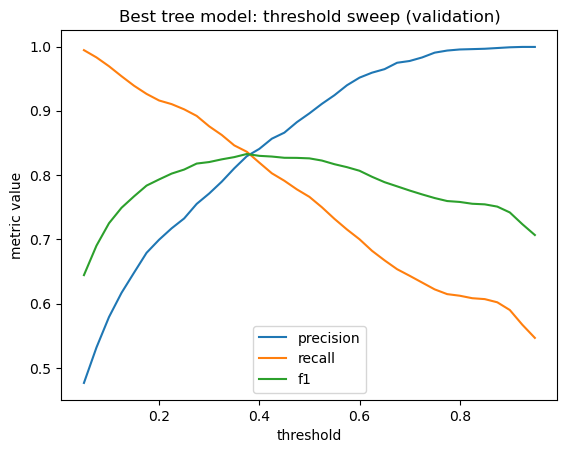

In [19]:
sweep = threshold_sweep(yva_c, p_va_best)

best_f1_row = sweep.sort_values("f1", ascending=False).iloc[0]
t_f1 = float(best_f1_row["threshold"])

RECALL_MIN = 0.80
eligible = sweep[sweep["recall"] >= RECALL_MIN]
t_recall = float(eligible.sort_values("precision", ascending=False).iloc[0]["threshold"]) if len(eligible) else t_f1

print("Best-F1 threshold:", t_f1, "F1:", float(best_f1_row["f1"]))
print("Recall>=%.2f threshold:" % RECALL_MIN, t_recall)

plt.figure()
plt.plot(sweep["threshold"], sweep["precision"], label="precision")
plt.plot(sweep["threshold"], sweep["recall"], label="recall")
plt.plot(sweep["threshold"], sweep["f1"], label="f1")
plt.xlabel("threshold")
plt.ylabel("metric value")
plt.title("Best tree model: threshold sweep (validation)")
plt.legend()
plt.show()

In [20]:
def per_1000_counts(tp, fp, tn, fn):
    n = tp + fp + tn + fn
    scale = 1000.0 / n if n > 0 else 0.0
    return {
        "TP_per_1000": tp * scale,
        "FP_per_1000": fp * scale,
        "TN_per_1000": tn * scale,
        "FN_per_1000": fn * scale,
    }

def report_with_counts(y_true, p, t, label):
    rep = eval_probs(y_true, p, threshold=t, label=label)
    tp, fp, tn, fn = confusion_counts(y_true, p, t)
    rep.update({"TP": tp, "FP": fp, "TN": tn, "FN": fn})
    rep.update(per_1000_counts(tp, fp, tn, fn))
    return rep

test_bestf1 = report_with_counts(yte_c, p_te_best, t_f1, label=best_clf_label.replace("_val", "_test_bestf1"))
test_recall = report_with_counts(yte_c, p_te_best, t_recall, label=best_clf_label.replace("_val", "_test_recall"))

print("Why NaNs appear:")
print("• ROC-AUC and Average Precision require a ranking of probabilities.")
print("  A constant predictor produces no ranking, so these metrics are undefined.")

print("• FP_per_1000 and FN_per_1000 require a probability threshold.")
print("  The majority baseline does not generate probabilities in this notebook,")
print("  so confusion-matrix based rates are not computed.\n")

pd.DataFrame([base_clf, test_bestf1, test_recall])[[
    "label","threshold","accuracy","precision","recall","f1","roc_auc","avg_precision",
    "FP_per_1000","FN_per_1000"
]]


Why NaNs appear:
• ROC-AUC and Average Precision require a ranking of probabilities.
  A constant predictor produces no ranking, so these metrics are undefined.
• FP_per_1000 and FN_per_1000 require a probability threshold.
  The majority baseline does not generate probabilities in this notebook,
  so confusion-matrix based rates are not computed.



,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,FP_per_1000,FN_per_1000
0,majority_predictor_test,NaN,0.622050,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
1,rf_n250_dNone_test_bestf1,0.375,0.871884,0.822881,0.842328,0.832491,0.940112,0.928043,68.524197,59.592054
2,rf_n250_dNone_test_recall,0.425,0.878416,0.858101,0.812698,0.834783,0.940112,0.928043,50.793228,70.790561


## 5D.14 - Slice evaluation for classification

We evaluate slice metrics by:
- `agency`
- `borough_norm`

Using the best-F1 threshold.


In [21]:
df_test_clf = df_clf.loc[Xte_c.index].copy()
df_test_clf["y"] = yte_c
df_test_clf["p"] = p_te_best
df_test_clf["yhat"] = (df_test_clf["p"] >= t_f1).astype(int)

def slice_metrics(g):
    y = g["y"].to_numpy()
    yhat = g["yhat"].to_numpy()
    p = g["p"].to_numpy()

    out = {
        "n": len(g),
        "precision": float(precision_score(y, yhat, zero_division=0)),
        "recall": float(recall_score(y, yhat, zero_division=0)),
        "f1": float(f1_score(y, yhat, zero_division=0)),
    }

    # ROC AUC is only defined if both classes are present
    if np.unique(y).size < 2:
        out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = float(roc_auc_score(y, p))

    return pd.Series(out)

MIN_N = 300

by_boro_clf = (
    df_test_clf
    .groupby("borough_norm")[["y", "yhat", "p"]]
    .apply(slice_metrics)
    .query("n >= @MIN_N")
    .sort_values("f1")
)

by_agency_clf = (
    df_test_clf
    .groupby("agency")[["y", "yhat", "p"]]
    .apply(slice_metrics)
    .query("n >= @MIN_N")
    .sort_values("f1")
)

display(by_boro_clf)
display(by_agency_clf.head(15))


,n,precision,recall,f1,roc_auc
borough_norm,,,,,
MANHATTAN,1311.0,0.749491,0.793103,0.770681,0.915185
STATEN ISLAND,398.0,0.836735,0.745455,0.788462,0.919492
BROOKLYN,2369.0,0.822665,0.840300,0.831389,0.930996
BRONX,1645.0,0.814540,0.857812,0.835616,0.943532
QUEENS,1774.0,0.881924,0.879360,0.880640,0.962633


,n,precision,recall,f1,roc_auc
agency,,,,,
DSNY,1955.0,0.500000,0.045113,0.082759,0.798759
HPD,2767.0,0.548090,0.640986,0.590909,0.834746
NYPD,1747.0,0.984545,1.000000,0.992212,0.943658


## 5D.15 - Classification feature importance

We inspect impurity-based feature importances from the best classification model.


In [22]:
best_clf_core = best_clf_model.named_steps["model"]
pre_best_clf = best_clf_model.named_steps["pre"]
clf_feature_names = list(pre_best_clf.get_feature_names_out())

if hasattr(best_clf_core, "feature_importances_"):
    imp_clf = pd.DataFrame({
        "feature": clf_feature_names,
        "importance": best_clf_core.feature_importances_
    }).sort_values("importance", ascending=False)
    display(imp_clf.head(20))
else:
    print("Best classification model does not expose feature_importances_.")

,feature,importance
21,agency_NYPD,0.317140
37,complaint_topk_illegal parking,0.101249
18,agency_DSNY,0.088519
42,complaint_topk_snow or ice,0.078625
20,agency_HPD,0.059552
7,street_number,0.045588
31,complaint_topk_blocked driveway,0.042235
38,complaint_topk_noise - residential,0.035861
0,created_hour,0.031250
35,complaint_topk_heat/hot water,0.028112


## 5D.16 - Inspect a shallow tree visually

A single shallow tree is the most interpretable tree-based model.
We only plot the first few levels. 
Remember we have normalized our features, and this can make the decision tree splits harder to understand.

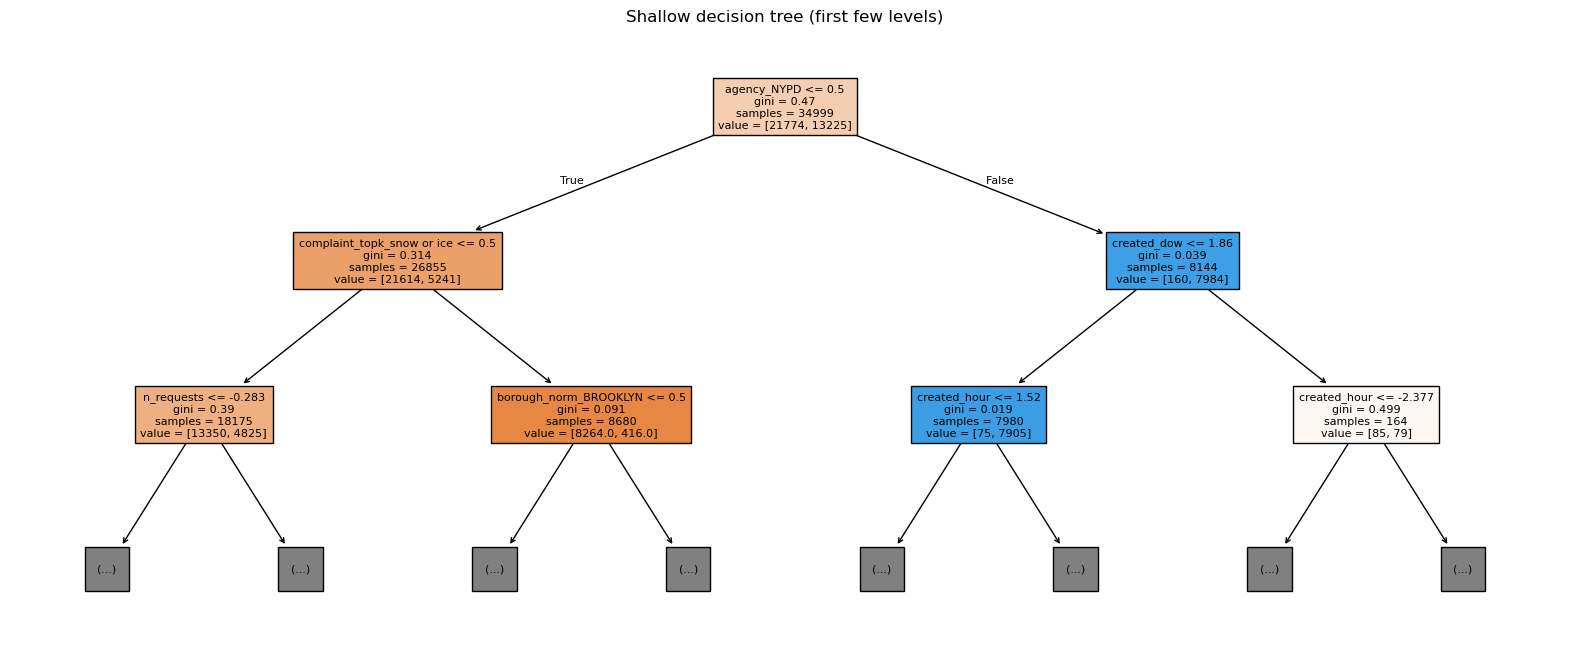

In [23]:
viz_tree = Pipeline([
    ("pre", pre_c),
    ("model", DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEED))
])
viz_tree.fit(Xtr_c, ytr_c)

viz_model = viz_tree.named_steps["model"]
viz_pre = viz_tree.named_steps["pre"]
viz_names = list(viz_pre.get_feature_names_out())

plt.figure(figsize=(20, 8))
plot_tree(
    viz_model,
    feature_names=viz_names,
    filled=True,
    max_depth=2,
    fontsize=8
)
plt.title("Shallow decision tree (first few levels)")
plt.show()

# Deliverable — Model choice memo

Write **10–14 bullets** using your actual outputs.

## Regression section
1) Which tree-based regressor performed best on validation?  
2) What was its **test MAE / RMSE / P90AbsErr**?  
3) How much did it improve over the **mean predictor**?  
4) What did the residual plots suggest?  
5) Which slice (agency or borough) had the worst error profile?  
6) Which features looked most important — and which importances do you distrust?

## Classification section
7) Which tree-based classifier performed best on validation?  
8) What threshold policy did you choose (best-F1 or recall-constrained)? Why?  
9) What were your **precision / recall / F1 / FP_per_1000 / FN_per_1000** on test?  
10) Which slice had the weakest F1?  
11) Did the tree model beat the majority baseline convincingly?  
12) Which features looked most important? What alternate explanation might exist?

## Final judgment
13) Would you deploy the tree-based model instead of the linear baseline from 5.A / 5.B?  
14) What do you gain, and what do you lose (interpretability, speed, stability, leakage risk)?

Paste your memo into the AI Tutor and ask:
> “Which of my reasons for trusting this tree model are weakest, and how would I stress-test them?”


## My Deliverable
### Regression
1. The best regression model on validation was `rf_n100_dNone` (uncapped Random Forest, 100 trees), with validation RMSE 7.01 and R2 0.696
2. On the test split `rf_n100_dNone` achieved MAE 4.29 hours, RMSE 7.49, and p90AbsErr 13.26 hours. Meaning 90% of predictions were within about 13 hours of true resolution time.
3. This represents a 42% reduction in RMSE over the mean predictor baseline (13.02), and R² improved from 0 to 0.669.
4. The residual plots revealed a ceiling effect and heteroscedasticity. Errors were small and symmetric for short resolution times, but became increasingly negative at higher predicted values
5. The worst agency slice was DOE (RMSE 15.36).
6. Agency indicators for HPD and NYPD accounted for ~63% of feature importance.

### Classification
7. The best classifier on validation was `rf_n250_none` (uncapped Random Forest, 250 trees), with ROC-AUC 0.943
8. The recall-constrained threshold (t=0.425) was chosen because it achieves slightly higher F1
9. On the test set at t=0.425: precision 0.858, recall 0.813, F1 0.835, FP_per_1000 50.8, FN_per_1000 70.8
10. The weakest slice was DSNY (F1 0.083)
11. The tree model beat the majority baseline. Accuracy rose from 62.2 to 87.8, and F1 went from 0 to 0.835
12. agency_NYPD and non-NYPD complaints

### Final Judgment
13. I would deploy the tree-based model instead of linear for both tasks. Regression RMSE improves ~42% and classification F1 improves from 0 to 0.835
14. The gains come at some costs. The random forest is a black box compared to a linear model. Individual predictions cannot be easily explained.

# Module 5.E - NYC 311, Margins, Kernels, and Model Selection  

**Algorithm comparison on a common evaluation protocol**

This notebook gives you hands-on practice with the core ideas from **Module 5.E**:

- **maximum margin intuition**
- **linear SVM**
- **kernel methods**
- **choosing between model families**

You will compare several model families on the **same NYC 311 classification task**:

- Logistic Regression
- Random Forest
- Gradient Boosting
- Linear SVM
- RBF SVM

And you will evaluate them using the evaluation habits from **Module 5.C**:

- random train / validation / test split
- precision / recall / F1
- ROC-AUC and Average Precision
- threshold sweeps
- confusion counts per 1,000
- slice analysis
- calibration

---

## Why this notebook matters
A professional ML workflow is not:

> train one algorithm and hope.

It is:

> train several plausible models → evaluate them rigorously → choose the best tradeoff.

This notebook is deliberately comparative.  
The goal is not just to get a score. The goal is to decide:

- which model family wins here
- why it wins
- what you gain and lose by choosing it

In [24]:
# === Setup ===
import os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    brier_score_loss, log_loss,
    roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

SEED = 42
rng = np.random.default_rng(SEED)

In [25]:
# === Paths ===
ARTIFACT_DIR = Path("work/m5/artifacts/nyc311")

clean_v2_path = ARTIFACT_DIR / "nyc311_features_clean_v2.parquet"
clean_path = ARTIFACT_DIR / "nyc311_features_clean.parquet"
config_v2_path = ARTIFACT_DIR / "feature_config_v2.json"
config_path = ARTIFACT_DIR / "feature_config.json"

def load_df():
    if clean_v2_path.exists():
        return pd.read_parquet(clean_v2_path), "m5_artifact_clean_v2"
    if clean_path.exists():
        return pd.read_parquet(clean_path), "m5_artifact_clean"
    raise FileNotFoundError(
        f"Could not find parquet at {clean_v2_path}, {clean_path}, or {fallback_m3}"
    )

df, df_source = load_df()
print("Loaded source:", df_source)
print("Shape:", df.shape)
display(df.head(3))

Loaded source: m5_artifact_clean_v2
Shape: (50000, 25)


,unique_key,created_date,created_day,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,closed_rate,median_resolution_hours,agency_n_requests,agency_closed_rate,agency_median_resolution,status,is_closed,resolution_hours,_source,created_dow
0,67720523,2026-01-30 01:51:21,2026-01-30,1,4,0,NYPD,(missing),other,1,1,0,0,NaN,280,0.435714,0.480972,11651,0.981890,1.277778,Unspecified,0,NaN,2.C_features_parquet,4
1,67746090,2026-01-30 01:51:04,2026-01-30,1,4,0,DOE,BROOKLYN,other,0,0,0,0,911.0,280,0.435714,0.480972,144,0.520833,7.605000,In Progress,0,NaN,2.C_features_parquet,4
2,67758820,2026-01-30 01:50:53,2026-01-30,1,4,0,NYPD,MANHATTAN,noise - residential,0,1,0,0,936.0,280,0.435714,0.480972,11651,0.981890,1.277778,In Progress,0,NaN,2.C_features_parquet,4


In [26]:
# Load feature config if available
config = None
if config_v2_path.exists():
    config = json.loads(config_v2_path.read_text())
    print("Loaded config:", config_v2_path.name)
elif config_path.exists():
    config = json.loads(config_path.read_text())
    print("Loaded config:", config_path.name)
else:
    print("No feature_config json found in", ARTIFACT_DIR)

Loaded config: feature_config.json


## 5E.2 - Build a preprocessing function (same style as 5.D)

We keep the same preprocessing pattern used in 5.B / 5.C / 5.D to avoid dtype and NaN surprises:

- numeric / bool columns → median impute + standardize
- categoricals → most frequent impute + one-hot encode
- datetime columns → dropped by default

This gives us a clean, repeatable pipeline.


In [27]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre

def describe_cols(X: pd.DataFrame):
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols

## 5E.3 - Define SAFE vs ALL feature sets

We will use a leakage-aware **SAFE** feature set by default.

Why this matters here:
- model comparison is only meaningful if the protocol is clean
- flexible models (especially trees and kernels) exploit leakage aggressively
- “the best model” under leakage is not actually the best model

This notebook focuses on **classification**, so we must drop direct outcome revealers.

In [28]:
DEFAULT_ID_COLS = ["unique_key", "_source"]
DEFAULT_TIME_COLS = ["created_date", "created_day"]
DEFAULT_OUTCOME = ["status", "is_closed", "resolution_hours"]

safe_drop = set()
all_drop = set()

if config is not None:
    safe_drop |= set(config.get("safe_drop", []))
    all_drop  |= set(config.get("all_drop", []))
else:
    safe_drop |= set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS + DEFAULT_OUTCOME)
    all_drop  |= set(DEFAULT_ID_COLS + DEFAULT_TIME_COLS)

# Classification-safe exclusions
safe_drop |= set(["is_closed", "status", "resolution_hours"])
all_drop  |= set(["is_closed", "resolution_hours"])

def build_X(df_in, drop_cols):
    cols = [c for c in df_in.columns if c not in drop_cols]
    return df_in[cols].copy(), cols

X_safe, safe_cols = build_X(df, safe_drop)
X_all, all_cols = build_X(df, all_drop)

print("SAFE features:", len(safe_cols))
print("ALL  features:", len(all_cols))
print("\nSAFE example columns:", safe_cols[:15])

SAFE features: 13
ALL  features: 18

SAFE example columns: ['created_hour', 'dayofweek', 'is_weekend', 'agency', 'borough_norm', 'complaint_topk', 'zip_missing', 'kw_noise', 'kw_rodent', 'kw_water', 'street_number', 'n_requests', 'created_dow']


## 5E.4 - Define the task and split randomly

We use the same main classification target from earlier notebooks:

- **Target:** `is_closed`

This is imperfect because some open cases may close later, but it is the practical label available at extraction time.

Because the dataset spans only ~6 days, we use **random stratified splits**, not temporal splits.


In [29]:
# === Classification target ===
if "is_closed" not in df.columns:
    raise ValueError("Expected is_closed in dataframe.")

y = df["is_closed"].astype(int).to_numpy()
X = X_safe

def split_random(X, y, stratify=None, seed=SEED, train=0.70, val=0.15, test=0.15):
    assert abs(train + val + test - 1.0) < 1e-9

    Xtr, Xtmp, ytr, ytmp = train_test_split(
        X, y, test_size=(1-train), random_state=seed, stratify=stratify
    )

    val_frac_of_tmp = val / (val + test)
    Xva, Xte, yva, yte = train_test_split(
        Xtmp, ytmp,
        test_size=(1-val_frac_of_tmp),
        random_state=seed,
        stratify=(ytmp if stratify is not None else None)
    )
    return Xtr, Xva, Xte, ytr, yva, yte

Xtr, Xva, Xte, ytr, yva, yte = split_random(X, y, stratify=y)

pre = build_preprocessor(Xtr)
num_cols, cat_cols, dt_cols = describe_cols(Xtr)

print("Rows:", len(df))
print("Split sizes:", len(ytr), len(yva), len(yte))
print("Positive rates:", float(ytr.mean()), float(yva.mean()), float(yte.mean()))
print("Feature types:", len(num_cols), "numeric |", len(cat_cols), "categorical |", len(dt_cols), "datetime dropped")
display(Xtr.head(3))

Rows: 50000
Split sizes: 34999 7500 7501
Positive rates: 0.3778679390839738 0.3778666666666667 0.3779496067191041
Feature types: 10 numeric | 3 categorical | 0 datetime dropped


,created_hour,dayofweek,is_weekend,agency,borough_norm,complaint_topk,zip_missing,kw_noise,kw_rodent,kw_water,street_number,n_requests,created_dow
46158,10,1,0,HPD,QUEENS,paint/plaster,0,0,0,0,40.0,17529,1
48383,8,1,0,HPD,BROOKLYN,electric,0,0,0,0,2447.0,17529,1
24542,12,2,0,HPD,BRONX,heat/hot water,0,0,0,0,295.0,16913,2


## 5E.5 - Shared evaluation helpers

In [30]:
def eval_probs(y_true, p, threshold=0.5, label=""):
    yhat = (p >= threshold).astype(int)
    out = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat, zero_division=0)),
        "recall": float(recall_score(y_true, yhat, zero_division=0)),
        "f1": float(f1_score(y_true, yhat, zero_division=0)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except Exception:
        out["roc_auc"] = float("nan")
    try:
        out["avg_precision"] = float(average_precision_score(y_true, p))
    except Exception:
        out["avg_precision"] = float("nan")
    try:
        out["brier"] = float(brier_score_loss(y_true, p))
    except Exception:
        out["brier"] = float("nan")
    try:
        out["log_loss"] = float(log_loss(y_true, p, labels=[0,1]))
    except Exception:
        out["log_loss"] = float("nan")
    return out

def threshold_sweep(y_true, p, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)
    rows = []
    for t in thresholds:
        rows.append(eval_probs(y_true, p, threshold=float(t)))
    return pd.DataFrame(rows)

def confusion_counts(y_true, p, t):
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
    return int(tp), int(fp), int(tn), int(fn)

def per_1000_counts(tp, fp, tn, fn):
    n = tp + fp + tn + fn
    scale = 1000.0 / n if n > 0 else 0.0
    return {
        "TP_per_1000": tp * scale,
        "FP_per_1000": fp * scale,
        "TN_per_1000": tn * scale,
        "FN_per_1000": fn * scale,
    }

def report_with_counts(y_true, p, t, label):
    rep = eval_probs(y_true, p, threshold=t, label=label)
    tp, fp, tn, fn = confusion_counts(y_true, p, t)
    rep.update({"TP": tp, "FP": fp, "TN": tn, "FN": fn})
    rep.update(per_1000_counts(tp, fp, tn, fn))
    return rep

# Part I - Baselines and Model-Family Comparison

We will fit five model families:

1. Logistic Regression  
2. Random Forest  
3. Gradient Boosting  
4. Linear SVM  
5. RBF SVM

## Practical note about SVMs
Kernel SVMs can become expensive on wide one-hot encoded data.

So for the SVMs we will use:
- the same preprocessing
- then **TruncatedSVD** to a compact dense embedding
- then SVM on that embedding

This is a pragmatic compromise:
- keeps runtime manageable
- still teaches margin and kernel ideas
- lets us compare under a shared protocol

## 5E.6 - Majority-class baseline

Before comparing sophisticated models, compute the simplest possible classifier.


In [31]:
majority_class = int(np.mean(ytr) >= 0.5)
yhat_majority = np.full_like(yte, majority_class)

baseline = {
    "label": "majority_predictor_test",
    "threshold": None,
    "accuracy": float(accuracy_score(yte, yhat_majority)),
    "precision": float(precision_score(yte, yhat_majority, zero_division=0)),
    "recall": float(recall_score(yte, yhat_majority, zero_division=0)),
    "f1": float(f1_score(yte, yhat_majority, zero_division=0)),
}
pd.DataFrame([baseline])

,label,threshold,accuracy,precision,recall,f1
0,majority_predictor_test,None,0.62205,0.0,0.0,0.0


## 5E.7 - Logistic Regression baseline

This is our standard classification baseline and a useful reference point for:
- interpretability
- calibration
- stability

In [32]:
logreg = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced"))
])

t0 = time.time()
logreg.fit(Xtr, ytr)
fit_time_logreg = time.time() - t0

p_va_log = logreg.predict_proba(Xva)[:,1]
log_val = eval_probs(yva, p_va_log, threshold=0.5, label="logreg_val")
log_val["fit_seconds"] = fit_time_logreg

pd.DataFrame([log_val])


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,fit_seconds
0,logreg_val,0.5,0.863333,0.817703,0.821454,0.819574,0.927833,0.919018,0.096483,0.313509,0.399259


## 5E.8 - Tree models on the full training set

We compare two strong tabular baselines:
- Random Forest
- Gradient Boosting

We keep the grid modest so the notebook remains responsive.


In [33]:
val_rows = []
model_store = {}

# Random Forest grid
for n_est in [150, 300]:
    for depth in [None, 10]:
        rf = Pipeline([
            ("pre", pre),
            ("model", RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=10,
                n_jobs=-1,
                random_state=SEED
            ))
        ])
        t0 = time.time()
        rf.fit(Xtr, ytr)
        fit_sec = time.time() - t0

        p_va = rf.predict_proba(Xva)[:,1]
        rep = eval_probs(yva, p_va, threshold=0.5, label=f"rf_n{n_est}_d{depth}_val")
        rep["fit_seconds"] = fit_sec
        rep["family"] = "RandomForest"
        rep["n_estimators"] = n_est
        rep["max_depth"] = depth
        val_rows.append(rep)
        model_store[rep["label"]] = rf

# Gradient Boosting grid
for lr in [0.03, 0.08]:
    for n_est in [120, 250]:
        gbc = Pipeline([
            ("pre", pre),
            ("model", GradientBoostingClassifier(
                learning_rate=lr,
                n_estimators=n_est,
                max_depth=3,
                subsample=0.8,
                random_state=SEED
            ))
        ])
        t0 = time.time()
        gbc.fit(Xtr, ytr)
        fit_sec = time.time() - t0

        p_va = gbc.predict_proba(Xva)[:,1]
        rep = eval_probs(yva, p_va, threshold=0.5, label=f"gbc_lr{lr}_n{n_est}_val")
        rep["fit_seconds"] = fit_sec
        rep["family"] = "GradientBoosting"
        rep["learning_rate"] = lr
        rep["n_estimators"] = n_est
        val_rows.append(rep)
        model_store[rep["label"]] = gbc

tree_val = pd.DataFrame(val_rows).sort_values(["avg_precision","roc_auc"], ascending=False)
display(tree_val.head(10))

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,fit_seconds,family,n_estimators,max_depth,learning_rate
2,rf_n300_dNone_val,0.5,0.878533,0.897150,0.766408,0.826641,0.943390,0.930331,0.086105,0.275760,4.023221,RandomForest,300,NaN,NaN
0,rf_n150_dNone_val,0.5,0.877867,0.897595,0.763938,0.825391,0.943183,0.930106,0.086247,0.276134,2.117981,RandomForest,150,NaN,NaN
7,gbc_lr0.08_n250_val,0.5,0.876533,0.892916,0.764996,0.824021,0.939047,0.927125,0.087668,0.281391,9.586628,GradientBoosting,250,NaN,0.08
6,gbc_lr0.08_n120_val,0.5,0.870800,0.892632,0.748059,0.813976,0.935332,0.923592,0.089793,0.290082,4.564049,GradientBoosting,120,NaN,0.08
1,rf_n150_d10_val,0.5,0.868133,0.938659,0.696542,0.799676,0.935698,0.923536,0.092482,0.301528,1.237103,RandomForest,150,10.0,NaN
5,gbc_lr0.03_n250_val,0.5,0.870933,0.916146,0.724771,0.809299,0.935285,0.923534,0.090273,0.292490,9.842145,GradientBoosting,250,NaN,0.03
3,rf_n300_d10_val,0.5,0.869333,0.938091,0.700423,0.802020,0.935453,0.923388,0.092705,0.302577,2.328167,RandomForest,300,10.0,NaN
4,gbc_lr0.03_n120_val,0.5,0.859333,0.971883,0.646436,0.776436,0.930362,0.915377,0.094717,0.309594,5.070945,GradientBoosting,120,NaN,0.03


## 5E.9 - SVMs on a reduced dense representation

One-hot encoded NYC 311 features produce a large sparse matrix.  
Kernel SVMs do not scale well in that regime.

So we do this:

- preprocess as usual
- reduce dimension with `TruncatedSVD`
- fit SVM in the dense embedding

We also use a **stratified subset of the training set** for SVM fitting.
That is not a bug — it reflects a realistic engineering compromise.

In [34]:
# Stratified subset for SVM training / validation to keep runtime reasonable
SVM_TRAIN_N = min(12000, len(Xtr))
SVM_VAL_N   = min(4000, len(Xva))

train_idx = pd.Series(ytr).groupby(ytr).sample(n=SVM_TRAIN_N // 2, random_state=SEED).index if len(np.unique(ytr)) == 2 else np.arange(SVM_TRAIN_N)
# safer generic approach:
idx_tr = train_test_split(np.arange(len(Xtr)), train_size=SVM_TRAIN_N, random_state=SEED, stratify=ytr)[0]
idx_va = train_test_split(np.arange(len(Xva)), train_size=SVM_VAL_N, random_state=SEED, stratify=yva)[0]

Xtr_svm = Xtr.iloc[idx_tr].copy()
ytr_svm = ytr[idx_tr]
Xva_svm = Xva.iloc[idx_va].copy()
yva_svm = yva[idx_va]

print("Full train size:", len(Xtr), "| SVM train subset:", len(Xtr_svm))
print("Full val size  :", len(Xva), "| SVM val subset  :", len(Xva_svm))
print("SVM train positive rate:", float(np.mean(ytr_svm)))


Full train size: 34999 | SVM train subset: 12000
Full val size  : 7500 | SVM val subset  : 4000
SVM train positive rate: 0.37783333333333335


In [35]:
# Fit the preprocessor once so we can inspect the transformed feature count
svm_pre = build_preprocessor(Xtr_svm)
svm_pre.fit(Xtr_svm)

# Number of columns after preprocessing (after imputation + scaling + one-hot)
n_features_after_pre = svm_pre.transform(Xtr_svm).shape[1]
print("Features after preprocessing:", n_features_after_pre)

# Pick a safe SVD dimension:
# - must be < n_features_after_pre
# - also keep it reasonably small for SVM runtime
default_n_components = 80
safe_n_components = min(default_n_components, max(2, n_features_after_pre - 1))
print("Using SVD n_components =", safe_n_components)

def make_svm_pipeline(kernel="linear", C=1.0, gamma="scale", n_components=None):
    if n_components is None:
        n_components = safe_n_components

    steps = [
        ("pre", svm_pre),
        ("svd", TruncatedSVD(n_components=n_components, random_state=SEED)),
        ("model", SVC(kernel=kernel, C=C, gamma=gamma, probability=True, random_state=SEED)),
    ]
    return Pipeline(steps)

svm_rows = []

# Linear SVM grid
for C in [0.3, 1.0, 3.0]:
    pipe = make_svm_pipeline(kernel="linear", C=C)
    t0 = time.time()
    pipe.fit(Xtr_svm, ytr_svm)
    fit_sec = time.time() - t0

    p_va = pipe.predict_proba(Xva_svm)[:, 1]
    rep = eval_probs(yva_svm, p_va, threshold=0.5, label=f"svm_linear_C{C}_val")
    rep["fit_seconds"] = fit_sec
    rep["family"] = "LinearSVM"
    rep["C"] = C
    rep["n_components"] = safe_n_components
    svm_rows.append(rep)
    model_store[rep["label"]] = pipe

# RBF SVM grid
for C in [1.0, 3.0]:
    for gamma in [0.1, 1.0]:
        pipe = make_svm_pipeline(kernel="rbf", C=C, gamma=gamma)
        t0 = time.time()
        pipe.fit(Xtr_svm, ytr_svm)
        fit_sec = time.time() - t0

        p_va = pipe.predict_proba(Xva_svm)[:, 1]
        rep = eval_probs(yva_svm, p_va, threshold=0.5, label=f"svm_rbf_C{C}_g{gamma}_val")
        rep["fit_seconds"] = fit_sec
        rep["family"] = "RBFSVM"
        rep["C"] = C
        rep["gamma"] = gamma
        rep["n_components"] = safe_n_components
        svm_rows.append(rep)
        model_store[rep["label"]] = pipe

svm_val = pd.DataFrame(svm_rows).sort_values(["avg_precision", "roc_auc"], ascending=False)
display(svm_val)


Features after preprocessing: 47
Using SVD n_components = 46


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,fit_seconds,family,C,n_components,gamma
3,svm_rbf_C1.0_g0.1_val,0.5,0.86625,0.875963,0.752482,0.809541,0.914275,0.907155,0.108124,0.362012,27.710970,RBFSVM,1.0,46,0.1
5,svm_rbf_C3.0_g0.1_val,0.5,0.86900,0.876430,0.760424,0.814316,0.911772,0.905523,0.106539,0.357768,28.212554,RBFSVM,3.0,46,0.1
0,svm_linear_C0.3_val,0.5,0.85250,0.940670,0.650563,0.769171,0.884356,0.876581,0.120245,0.394035,22.266413,LinearSVM,0.3,46,NaN
2,svm_linear_C3.0_val,0.5,0.85250,0.940670,0.650563,0.769171,0.882192,0.875460,0.120349,0.394823,34.936491,LinearSVM,3.0,46,NaN
4,svm_rbf_C1.0_g1.0_val,0.5,0.86550,0.867170,0.760424,0.810296,0.898253,0.872632,0.109673,0.370604,38.781337,RBFSVM,1.0,46,1.0
1,svm_linear_C1.0_val,0.5,0.85250,0.940670,0.650563,0.769171,0.875578,0.867986,0.120349,0.394824,24.209078,LinearSVM,1.0,46,NaN
6,svm_rbf_C3.0_g1.0_val,0.5,0.86450,0.859688,0.766380,0.810357,0.890293,0.855753,0.111708,0.378209,37.983523,RBFSVM,3.0,46,1.0


## 5E.10 - Validation leaderboard across model families

We combine:
- Logistic Regression
- the tree models
- the SVM models

Because the SVMs were tuned on a subset, compare them thoughtfully:
- a strong score still matters
- but runtime and scalability also matter


In [36]:
leaderboard = pd.concat([
    pd.DataFrame([log_val]),
    tree_val,
    svm_val
], ignore_index=True)

leaderboard = leaderboard.sort_values(["avg_precision", "roc_auc", "f1"], ascending=False)
display(leaderboard[[
    "label","family","accuracy","precision","recall","f1",
    "roc_auc","avg_precision","brier","fit_seconds"
]].head(15))


,label,family,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,fit_seconds
1,rf_n300_dNone_val,RandomForest,0.878533,0.897150,0.766408,0.826641,0.943390,0.930331,0.086105,4.023221
2,rf_n150_dNone_val,RandomForest,0.877867,0.897595,0.763938,0.825391,0.943183,0.930106,0.086247,2.117981
3,gbc_lr0.08_n250_val,GradientBoosting,0.876533,0.892916,0.764996,0.824021,0.939047,0.927125,0.087668,9.586628
4,gbc_lr0.08_n120_val,GradientBoosting,0.870800,0.892632,0.748059,0.813976,0.935332,0.923592,0.089793,4.564049
5,rf_n150_d10_val,RandomForest,0.868133,0.938659,0.696542,0.799676,0.935698,0.923536,0.092482,1.237103
6,gbc_lr0.03_n250_val,GradientBoosting,0.870933,0.916146,0.724771,0.809299,0.935285,0.923534,0.090273,9.842145
7,rf_n300_d10_val,RandomForest,0.869333,0.938091,0.700423,0.802020,0.935453,0.923388,0.092705,2.328167
0,logreg_val,NaN,0.863333,0.817703,0.821454,0.819574,0.927833,0.919018,0.096483,0.399259
8,gbc_lr0.03_n120_val,GradientBoosting,0.859333,0.971883,0.646436,0.776436,0.930362,0.915377,0.094717,5.070945
9,svm_rbf_C1.0_g0.1_val,RBFSVM,0.866250,0.875963,0.752482,0.809541,0.914275,0.907155,0.108124,27.710970


# Part II — Threshold policies and test-set comparison

Now we pick a few finalists and apply the same threshold-selection logic to each.

We will compare these five finalists:
- Logistic Regression
- best Random Forest
- best Gradient Boosting
- best Linear SVM
- best RBF SVM

For each finalist:
1. choose threshold by **best validation F1**
2. evaluate on **test**
3. translate confusion counts to **per 1,000 cases**

In [37]:
# Pick finalists
best_rf_label = tree_val.query("family == 'RandomForest'").sort_values(["avg_precision","roc_auc"], ascending=False).iloc[0]["label"]
best_gbc_label = tree_val.query("family == 'GradientBoosting'").sort_values(["avg_precision","roc_auc"], ascending=False).iloc[0]["label"]
best_lin_svm_label = svm_val.query("family == 'LinearSVM'").sort_values(["avg_precision","roc_auc"], ascending=False).iloc[0]["label"]
best_rbf_svm_label = svm_val.query("family == 'RBFSVM'").sort_values(["avg_precision","roc_auc"], ascending=False).iloc[0]["label"]

finalists = {
    "LogisticRegression": logreg,
    "RandomForest": model_store[best_rf_label],
    "GradientBoosting": model_store[best_gbc_label],
    "LinearSVM": model_store[best_lin_svm_label],
    "RBFSVM": model_store[best_rbf_svm_label],
}

print("Finalists:")
for k,v in finalists.items():
    print("-", k)


Finalists:
- LogisticRegression
- RandomForest
- GradientBoosting
- LinearSVM
- RBFSVM


In [38]:
# Validation probabilities for each finalist
# Important: SVM finalists were fit on subset, but we can still score the full validation and test sets
val_probs = {}
test_probs = {}

for name, model in finalists.items():
    val_probs[name] = model.predict_proba(Xva)[:,1]
    test_probs[name] = model.predict_proba(Xte)[:,1]

# Thresholds chosen by best F1 on validation
chosen_thresholds = {}
for name, p in val_probs.items():
    sweep = threshold_sweep(yva, p)
    t_star = float(sweep.sort_values("f1", ascending=False).iloc[0]["threshold"])
    chosen_thresholds[name] = t_star

chosen_thresholds

{'LogisticRegression': 0.49999999999999994,
 'RandomForest': 0.37499999999999994,
 'GradientBoosting': 0.39999999999999997,
 'LinearSVM': 0.2,
 'RBFSVM': 0.175}

In [39]:
# Test comparison at chosen threshold
test_rows = []
for name, p in test_probs.items():
    t = chosen_thresholds[name]
    test_rows.append(report_with_counts(yte, p, t, label=f"{name}_test"))

test_table = pd.DataFrame(test_rows).sort_values(["avg_precision","f1","roc_auc"], ascending=False)
display(test_table[[
    "label","threshold","accuracy","precision","recall","f1",
    "roc_auc","avg_precision","brier","log_loss",
    "FP_per_1000","FN_per_1000"
]])

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,FP_per_1000,FN_per_1000
1,RandomForest_test,0.375,0.872150,0.823448,0.842328,0.832781,0.940234,0.928267,0.087112,0.282009,68.257566,59.592054
2,GradientBoosting_test,0.400,0.869884,0.832320,0.821164,0.826705,0.934793,0.923931,0.089616,0.289967,62.524997,67.590988
0,LogisticRegression_test,0.500,0.856686,0.803658,0.821517,0.812489,0.920810,0.913535,0.100625,0.327635,75.856552,67.457672
4,RBFSVM_test,0.175,0.866151,0.834246,0.805996,0.819878,0.915409,0.907663,0.107582,0.360565,60.525263,73.323557
3,LinearSVM_test,0.200,0.859085,0.927815,0.680071,0.784857,0.880198,0.874197,0.118675,0.388551,19.997334,120.917211


## 5E.11 - Threshold-sweep comparison for finalists

The same model can behave very differently under different thresholds.

Plotting threshold sweeps helps answer:
- which models are stable across thresholds
- which models are only good in narrow operating regions

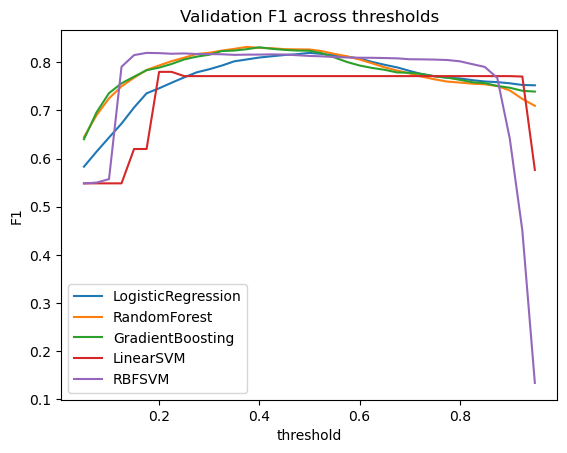

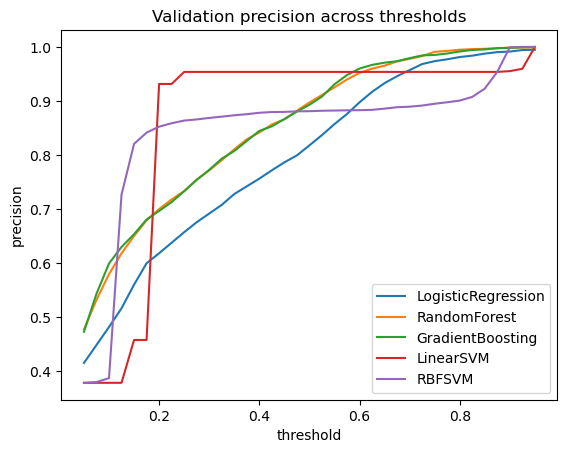

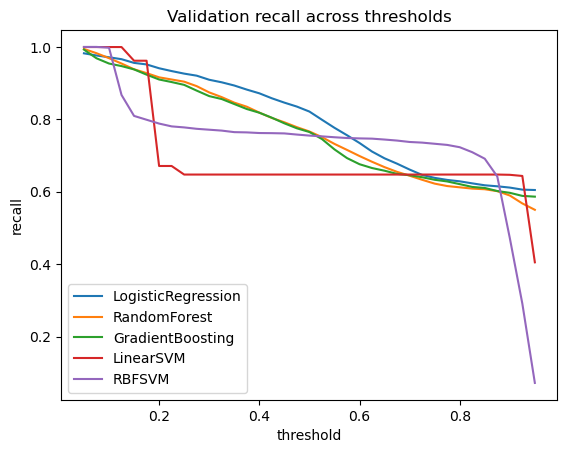

In [40]:
plt.figure()
for name, p in val_probs.items():
    sweep = threshold_sweep(yva, p)
    plt.plot(sweep["threshold"], sweep["f1"], label=name)
plt.xlabel("threshold")
plt.ylabel("F1")
plt.title("Validation F1 across thresholds")
plt.legend()
plt.show()

plt.figure()
for name, p in val_probs.items():
    sweep = threshold_sweep(yva, p)
    plt.plot(sweep["threshold"], sweep["precision"], label=name)
plt.xlabel("threshold")
plt.ylabel("precision")
plt.title("Validation precision across thresholds")
plt.legend()
plt.show()

plt.figure()
for name, p in val_probs.items():
    sweep = threshold_sweep(yva, p)
    plt.plot(sweep["threshold"], sweep["recall"], label=name)
plt.xlabel("threshold")
plt.ylabel("recall")
plt.title("Validation recall across thresholds")
plt.legend()
plt.show()

# PART III - ROC, PR, and Calibration

Now we compare the finalists from three different perspectives:

1. **ROC** — ranking quality across thresholds  
2. **PR** — performance under class imbalance  
3. **Calibration** — whether probabilities mean what they say


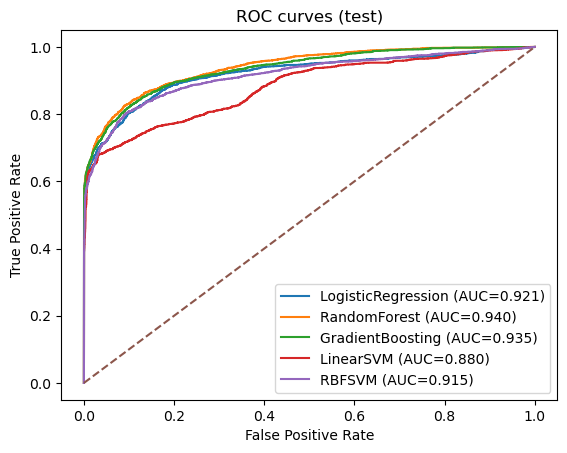

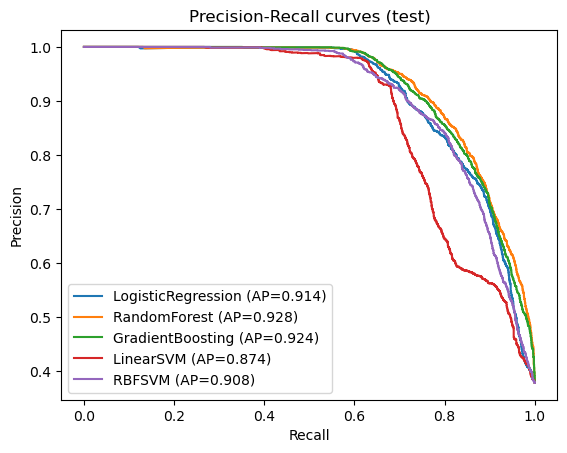

In [41]:
# ROC curves
plt.figure()
for name, p in test_probs.items():
    fpr, tpr, _ = roc_curve(yte, p)
    auc = roc_auc_score(yte, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (test)")
plt.legend()
plt.show()

# PR curves
plt.figure()
for name, p in test_probs.items():
    prec, rec, _ = precision_recall_curve(yte, p)
    ap = average_precision_score(yte, p)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (test)")
plt.legend()
plt.show()


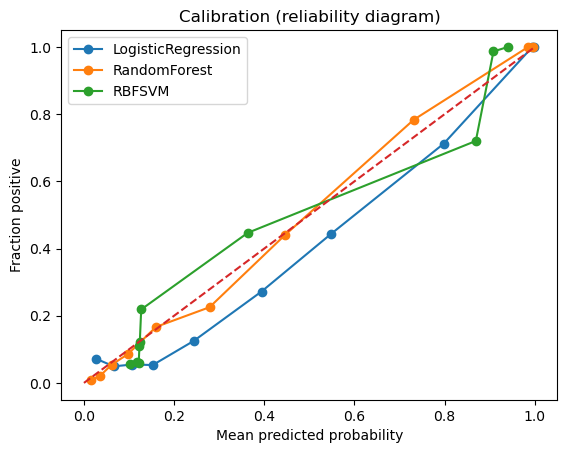

,model,brier,log_loss
1,RandomForest,0.087112,0.282009
2,GradientBoosting,0.089616,0.289967
0,LogisticRegression,0.100625,0.327635
4,RBFSVM,0.107582,0.360565
3,LinearSVM,0.118675,0.388551


In [42]:
# Calibration curves for three especially interesting models
calib_names = ["LogisticRegression", "RandomForest", "RBFSVM"]

plt.figure()
for name in calib_names:
    prob_true, prob_pred = calibration_curve(yte, test_probs[name], n_bins=10, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o", label=name)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction positive")
plt.title("Calibration (reliability diagram)")
plt.legend()
plt.show()

calib_table = []
for name in finalists:
    calib_table.append({
        "model": name,
        "brier": float(brier_score_loss(yte, test_probs[name])),
        "log_loss": float(log_loss(yte, test_probs[name], labels=[0,1])),
    })
pd.DataFrame(calib_table).sort_values("brier")


# Part IV — What each model is actually “using”

Model comparison is not just about scores.
You also want to understand **what signal each family is relying on**.

We will inspect:
- logistic regression coefficients
- tree feature importance
- support-vector counts


## 5E.12 - Logistic Regression coefficients

This gives the clearest signed interpretation:
- positive coefficient → pushes probability up
- negative coefficient → pushes probability down

In [44]:
pre_log = logreg.named_steps["pre"]
feature_names_log = list(pre_log.get_feature_names_out())
coefs = logreg.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({"feature": feature_names_log, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

print("Top positive coefficients:")
display(coef_df.sort_values("coef", ascending=False).head(15))

print("Top negative coefficients:")
display(coef_df.sort_values("coef", ascending=True).head(15))

Top positive coefficients:


,feature,coef,abs_coef
21,agency_NYPD,6.262505,6.262505
43,complaint_topk_traffic signal condition,1.718001,1.718001
35,complaint_topk_heat/hot water,1.579824,1.579824
14,agency_DOE,1.055781,1.055781
36,complaint_topk_homeless person assistance,0.885409,0.885409
11,agency_DEP,0.784644,0.784644
46,complaint_topk_water system,0.476610,0.476610
8,n_requests,0.462886,0.462886
40,complaint_topk_paint/plaster,0.374902,0.374902
30,borough_norm_STATEN ISLAND,0.212164,0.212164


Top negative coefficients:


,feature,coef,abs_coef
19,agency_EDC,-2.898802,2.898802
42,complaint_topk_snow or ice,-2.102217,2.102217
22,agency_OOS,-1.651153,1.651153
20,agency_HPD,-1.282710,1.282710
25,borough_norm_(missing),-1.259542,1.259542
32,complaint_topk_door/window,-0.857347,0.857347
34,complaint_topk_general,-0.827751,0.827751
45,complaint_topk_water leak,-0.782207,0.782207
44,complaint_topk_unsanitary condition,-0.691135,0.691135
24,agency_TLC,-0.606636,0.606636


## 5E.13 - Tree feature importance

Tree importance is useful, but remember:
- correlated features can split credit
- importance is a clue, not truth


In [45]:
tree_importance_tables = {}

for name in ["RandomForest", "GradientBoosting"]:
    model = finalists[name]
    pre_model = model.named_steps["pre"]
    core = model.named_steps["model"]
    f_names = list(pre_model.get_feature_names_out())

    if hasattr(core, "feature_importances_"):
        imp = pd.DataFrame({
            "feature": f_names,
            "importance": core.feature_importances_
        }).sort_values("importance", ascending=False)
        tree_importance_tables[name] = imp
        print(name)
        display(imp.head(20))


RandomForest


,feature,importance
21,agency_NYPD,0.324113
37,complaint_topk_illegal parking,0.102534
18,agency_DSNY,0.087521
42,complaint_topk_snow or ice,0.076692
20,agency_HPD,0.056397
7,street_number,0.045521
31,complaint_topk_blocked driveway,0.041980
38,complaint_topk_noise - residential,0.037126
0,created_hour,0.031440
35,complaint_topk_heat/hot water,0.027785


GradientBoosting


,feature,importance
21,agency_NYPD,0.734252
8,n_requests,0.054564
42,complaint_topk_snow or ice,0.047296
35,complaint_topk_heat/hot water,0.038290
11,agency_DEP,0.019694
43,complaint_topk_traffic signal condition,0.017571
1,dayofweek,0.014613
0,created_hour,0.012850
7,street_number,0.012478
9,created_dow,0.010446


## 5E.14 - Support vectors: how much of the data defines the boundary?

A useful SVM-specific diagnostic:
- how many support vectors are needed?
- what fraction of the SVM training subset becomes support vectors?

If that fraction is large, the boundary may be more complex / less stable.

In [46]:
svm_support_info = []

for name in ["LinearSVM", "RBFSVM"]:
    model = finalists[name]
    core = model.named_steps["model"]
    if hasattr(core, "support_vectors_"):
        n_sv = len(core.support_vectors_)
        n_train = len(Xtr_svm)  # SVMs fit on subset
        svm_support_info.append({
            "model": name,
            "n_support_vectors": n_sv,
            "train_subset_size": n_train,
            "support_vector_fraction": n_sv / n_train
        })

pd.DataFrame(svm_support_info)

,model,n_support_vectors,train_subset_size,support_vector_fraction
0,LinearSVM,4013,12000,0.334417
1,RBFSVM,3839,12000,0.319917


# Part V — Slice analysis and final model choice

Overall metrics can hide weak slices.
We will evaluate finalists by:
- `borough_norm`
- `agency`

using the chosen threshold for each model.


In [48]:
def slice_report(df_base, y_true, p, threshold, group_col, min_n=300):
    temp = df_base.copy()
    temp["y"] = y_true
    temp["p"] = p
    temp["yhat"] = (temp["p"] >= threshold).astype(int)

    def agg(g):
        y = g["y"].to_numpy()
        yhat = g["yhat"].to_numpy()
        p = g["p"].to_numpy()
        out = {
            "n": len(g),
            "precision": float(precision_score(y, yhat, zero_division=0)),
            "recall": float(recall_score(y, yhat, zero_division=0)),
            "f1": float(f1_score(y, yhat, zero_division=0)),
        }
        try:
            out["roc_auc"] = float(roc_auc_score(y, p))
        except Exception:
            out["roc_auc"] = float("nan")
        return pd.Series(out)

    result = temp.groupby(group_col).apply(agg)
    result = result.query("n >= @min_n").sort_values("f1")
    return result

df_test_base = df.loc[Xte.index].copy()

# Choose one “deployment candidate” = best avg_precision on test table
deploy_name = test_table.sort_values(["avg_precision","f1","roc_auc"], ascending=False).iloc[0]["label"].replace("_test","")
deploy_threshold = chosen_thresholds[deploy_name]
deploy_probs = test_probs[deploy_name]

print("Deployment candidate:", deploy_name)
print("Chosen threshold:", deploy_threshold)

boro_slice = slice_report(df_test_base, yte, deploy_probs, deploy_threshold, group_col="borough_norm", min_n=300)
agency_slice = slice_report(df_test_base, yte, deploy_probs, deploy_threshold, group_col="agency", min_n=300)

display(boro_slice)
display(agency_slice.head(15))

Deployment candidate: RandomForest
Chosen threshold: 0.37499999999999994


,n,precision,recall,f1,roc_auc
borough_norm,,,,,
MANHATTAN,1311.0,0.743952,0.795259,0.768750,0.915060
STATEN ISLAND,398.0,0.845361,0.745455,0.792271,0.919555
BROOKLYN,2369.0,0.826133,0.840300,0.833156,0.931288
BRONX,1645.0,0.815476,0.856250,0.835366,0.943704
QUEENS,1774.0,0.881924,0.879360,0.880640,0.962630


,n,precision,recall,f1,roc_auc
agency,,,,,
DSNY,1955.0,0.500000,0.045113,0.082759,0.800455
HPD,2767.0,0.550993,0.640986,0.592593,0.834724
NYPD,1747.0,0.984545,1.000000,0.992212,0.946286


## 5E.15 - One last question: is the most accurate model the one you would deploy?

Use the evidence you now have:

- validation / test metrics
- threshold stability
- ROC / PR / calibration
- interpretability
- fit time / scalability
- slice robustness

A professional model choice is a tradeoff decision, not just a leaderboard decision.


# Deliverable — Model selection memo

Write **14 bullets** using actual values from your outputs.

1. Which model family had the best **validation** performance?  
2. Which model family had the best **test** performance?  
3. Did the winner under **Average Precision** also win under **F1**?  
4. Which model had the best **calibration** (Brier / reliability diagram)?  
5. Which model was most expensive to train?  
6. Which model looked most interpretable?  
7. Which model family was most sensitive to threshold choice?  
8. What did the **support vector fraction** suggest about the SVMs?  
9. What did the **tree importances** suggest — and what do you distrust about them?  
10. Which slice (borough or agency) looked weakest for your deployment candidate?  
11. If you cared more about recall than precision, would you pick a different model or just a different threshold?  
12. Would you deploy the most accurate model, or a slightly weaker but simpler one? Why?  
13. What would you monitor in production?  
14. What dataset shift would most likely break your chosen model first?

In [50]:
# Deliverable — model selection memo (auto-generated from notebook variables)

def safe_first(df, sort_cols, ascending=False):
    if df is None or len(df) == 0:
        return None
    return df.sort_values(sort_cols, ascending=ascending).iloc[0]

def fmt(x, nd=3):
    try:
        if pd.isna(x):
            return "nan"
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

# 1) Best validation performance
val_best = leaderboard.sort_values(["avg_precision", "roc_auc", "f1"], ascending=False).iloc[0]

# 2) Best test performance
test_best = test_table.sort_values(["avg_precision", "f1", "roc_auc"], ascending=False).iloc[0]

# 3) Winner under AP vs F1
test_best_ap = test_table.sort_values(["avg_precision", "roc_auc"], ascending=False).iloc[0]
test_best_f1 = test_table.sort_values(["f1", "avg_precision"], ascending=False).iloc[0]

# 4) Best calibration
if isinstance(calib_table, list):
    calib_df = pd.DataFrame(calib_table)
else:
    calib_df = calib_table

best_cal = calib_df.sort_values(["brier", "log_loss"], ascending=True).iloc[0]

# 5) Most expensive to train
train_cost = leaderboard.sort_values("fit_seconds", ascending=False).iloc[0]

# 6) Most interpretable
interpretable_model = "LogisticRegression"

# 7) Threshold sensitivity
# Use validation threshold sweeps across finalists
threshold_sensitivity_rows = []
for name, p in val_probs.items():
    sweep = threshold_sweep(yva, p)
    f1_range = float(sweep["f1"].max() - sweep["f1"].min())
    precision_range = float(sweep["precision"].max() - sweep["precision"].min())
    recall_range = float(sweep["recall"].max() - sweep["recall"].min())
    threshold_sensitivity_rows.append({
        "model": name,
        "f1_range": f1_range,
        "precision_range": precision_range,
        "recall_range": recall_range,
    })
threshold_sensitivity = pd.DataFrame(threshold_sensitivity_rows)
most_threshold_sensitive = threshold_sensitivity.sort_values("f1_range", ascending=False).iloc[0]

# 8) Support vector fraction
if "svm_support_info" in globals() and len(svm_support_info) > 0:
    svm_sv = pd.DataFrame(svm_support_info).sort_values("support_vector_fraction", ascending=False)
    svm_sv_summary = "; ".join(
        f"{row['model']}: {fmt(row['support_vector_fraction'])}"
        for _, row in svm_sv.iterrows()
    )
else:
    svm_sv_summary = "No support-vector info available."

# 9) Tree importances
tree_imp_summaries = []
if "tree_importance_tables" in globals() and len(tree_importance_tables) > 0:
    for name, imp in tree_importance_tables.items():
        top_feats = ", ".join(imp.head(5)["feature"].tolist())
        tree_imp_summaries.append(f"{name}: {top_feats}")
tree_imp_summary = " | ".join(tree_imp_summaries) if tree_imp_summaries else "No tree importance tables available."

# 10) Weakest slice for deployment candidate
weak_boro = boro_slice.sort_values("f1", ascending=True).iloc[0] if len(boro_slice) > 0 else None
weak_boro_name = boro_slice.sort_values("f1", ascending=True).index[0] if len(boro_slice) > 0 else "N/A"

weak_agency = agency_slice.sort_values("f1", ascending=True).iloc[0] if len(agency_slice) > 0 else None
weak_agency_name = agency_slice.sort_values("f1", ascending=True).index[0] if len(agency_slice) > 0 else "N/A"

# choose whichever is worse by F1
if weak_boro is not None and weak_agency is not None:
    if float(weak_boro["f1"]) <= float(weak_agency["f1"]):
        weakest_slice_name = f"borough {weak_boro_name}"
        weakest_slice_row = weak_boro
    else:
        weakest_slice_name = f"agency {weak_agency_name}"
        weakest_slice_row = weak_agency
else:
    weakest_slice_name = "N/A"
    weakest_slice_row = None

# 11) Recall vs precision decision
recall_best = test_table.sort_values(["recall", "avg_precision"], ascending=False).iloc[0]

# 12) Deployment tradeoff
deploy_row = test_table[test_table["label"] == f"{deploy_name}_test"]
deploy_row = deploy_row.iloc[0] if len(deploy_row) else test_best

# 13) Monitoring suggestions
monitor_items = [
    "positive-rate drift",
    "precision drift",
    "recall drift",
    "threshold operating point drift",
    "feature-distribution drift by agency and borough",
]

# 14) Likely dataset shift
likely_shift = "changes in complaint mix, agency behavior, or closure workflow that alter the relationship between request features and is_closed"

bullets = [
    f"1. Best validation performance: **{val_best['label']}** with Average Precision={fmt(val_best['avg_precision'])}, ROC-AUC={fmt(val_best['roc_auc'])}, and F1={fmt(val_best['f1'])}.",
    f"2. Best test performance: **{test_best['label']}** with Average Precision={fmt(test_best['avg_precision'])}, ROC-AUC={fmt(test_best['roc_auc'])}, and F1={fmt(test_best['f1'])}.",
    f"3. Winner under Average Precision: **{test_best_ap['label']}**; winner under F1: **{test_best_f1['label']}**; same winner? **{'Yes' if test_best_ap['label'] == test_best_f1['label'] else 'No'}**.",
    f"4. Best calibration by Brier/log loss: **{best_cal['model']}** with Brier={fmt(best_cal['brier'])} and log loss={fmt(best_cal['log_loss'])}.",
    f"5. Most expensive model to train: **{train_cost['label']}** with fit time ≈ {fmt(train_cost['fit_seconds'], 2)} seconds.",
    f"6. Most interpretable model: **{interpretable_model}**, because coefficients provide direct signed feature effects and are easier to explain than tree importances or kernel boundaries.",
    f"7. Most threshold-sensitive model family: **{most_threshold_sensitive['model']}** with validation F1 range={fmt(most_threshold_sensitive['f1_range'])} across thresholds.",
    f"8. Support vector fraction summary: {svm_sv_summary}. A larger fraction suggests the boundary depends on many training examples and may be more complex or less stable.",
    f"9. Tree importances suggested these top signals: {tree_imp_summary}. I distrust them when features are correlated or when high-cardinality one-hot features split credit unpredictably.",
    f"10. Weakest slice for deployment candidate **{deploy_name}**: **{weakest_slice_name}** with n={int(weakest_slice_row['n']) if weakest_slice_row is not None else 'N/A'} and F1={fmt(weakest_slice_row['f1']) if weakest_slice_row is not None else 'N/A'}.",
    f"11. If recall mattered more than precision, I would first change the **threshold** rather than switch models; the strongest recall-oriented test model here is **{recall_best['label']}** with recall={fmt(recall_best['recall'])}.",
    f"12. I would deploy **{deploy_name}** at threshold={fmt(deploy_threshold, 2)} if I wanted the best measured operating tradeoff; otherwise I would consider **LogisticRegression** if a slightly weaker but simpler, more interpretable model is preferred.",
    f"13. In production I would monitor: {', '.join(monitor_items)}.",
    f"14. The most likely dataset shift to break this model first is **{likely_shift}**."
]

print("# Deliverable — Model selection memo\\n")
for b in bullets:
    print("-", b)

# Deliverable — Model selection memo\n
- 1. Best validation performance: **rf_n300_dNone_val** with Average Precision=0.930, ROC-AUC=0.943, and F1=0.827.
- 2. Best test performance: **RandomForest_test** with Average Precision=0.928, ROC-AUC=0.940, and F1=0.833.
- 3. Winner under Average Precision: **RandomForest_test**; winner under F1: **RandomForest_test**; same winner? **Yes**.
- 4. Best calibration by Brier/log loss: **RandomForest** with Brier=0.087 and log loss=0.282.
- 5. Most expensive model to train: **svm_rbf_C1.0_g1.0_val** with fit time ≈ 38.78 seconds.
- 6. Most interpretable model: **LogisticRegression**, because coefficients provide direct signed feature effects and are easier to explain than tree importances or kernel boundaries.
- 7. Most threshold-sensitive model family: **RBFSVM** with validation F1 range=0.685 across thresholds.
- 8. Support vector fraction summary: LinearSVM: 0.334; RBFSVM: 0.320. A larger fraction suggests the boundary depends on many training ex